### Topics Covered
- Introduction to Graphs
- Adding Vertices and Edges
- Removing Vertices and Edges
- Breadth First Traversal
- Depth First Traversal Iterative
- Depth First Traversal Recursive
- Use Cases

### Introduction

Trees improved on the regular linked lists by allowing nodes to have more than one connection, giving us the possibility to represent hierarchy. But trees still had some limitations. Some connections were not allowed for certain nodes. For example, children couldn't have more than one parent and siblings couldn't share a connection. In a graph, all these limitations are lifted. Generally, there are no rules as to which node can be connected to which. In this sense, a graph can be simply defined as a data structure which contains some nodes and all the connections between them. In graph terminology, a node is generally called a **vertex** with **vertices** for the plural, and just like before, they can represent any type of information we want

In the graph we have here, our vertices are the letters from A to k. The connections between them are still called edges, just like in a tree. And you can now see that we don't have a hierarchy anymore, and we're free to connect whichever vertices we want. Also, there are no rules as to how many connections a vertex can have. There are some in this graph that have two, and there are some with 3 or 4.Graph theory is one of the biggest topics in the study of mathematical objects, and graphs come in many variations.


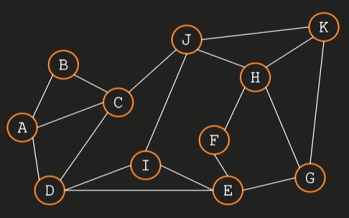

So the graph we have here is called an **undirected simple graph**. It's undirected because our edges do not represent a particular direction from one node to another. In that regard, `J` has a connection to `K`, and at the same time `K` shares that same connection to `J`

Let's assume this topic was describing this relation as a handshake between two people. If person `A` and person `B` shook hands, they would share a mutual connection. We can't say that `A` is shaking `B's` hand, but `B` does not shake `A's`. They share a connection that does not imply any direction. The graph is described as simple because any two nodes can only have one edge between them, like the one we see here. If two nodes were joined by more than one edge, we would call that a **multigraph**.

**Definition** : A  **vertex** (also called a node) is a fundamental unit that represents an entity—like a city in a map, a person in a social network, or a stock in a financial graph.

An **edge** is the connection or relationship between two vertices—like a road between cities or a friendship between people.
Here’s a simple way to visualize it using a dictionary-based graph:

graph = {
 - "A": ["B", "C"],
 - "B": ["A", "D"],
 - "C": ["A", "D"],
 - "D": ["B", "C"]
}

   - **Vertices**: "A", "B", "C", "D"
   - **Edges**: ("A", "B"), ("A", "C"), ("B", "D"), ("C", "D")
Each key in the dictionary is a vertex, and its list of values represents the vertices it's connected to via edges.


In some scenarios, edges can represent a direction. The graph would then become a **directed graph**, also called **digraph** for short. In such a case, we can say that B has a connection to C, but C does not share that connection. A classic example of this relation is a one way street. You're allowed to drive from one end to the other, but not the other way round.

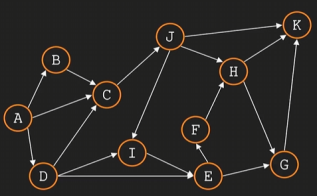

In some graphs we can assign numbers to edges. The structure we have now is called a **weighted graph**, and although the numbers associated with the edges are normally called weights, they can represent any type of value depending on the context. They can be distances between two points in space. They can be the intensity of an electric current or any value that describes that connection.

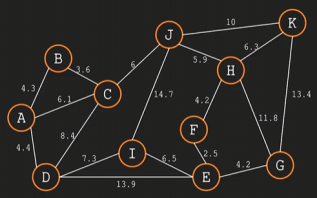

And of course we can have a mixture of all these types of graphs. The one we see here is both weighted and directed

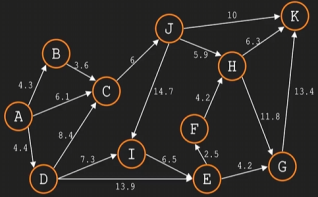

Because of their versatility, graphs can represent a large variety of relations and situations from many real world domains. One, which we're very much used to is the social network using a graph. We can model all the relationships and friendship statuses we see in an app such as Facebook. The vertices would be the users, and whenever they befriend or unfriend someone, an edge would either be created or removed between them. 

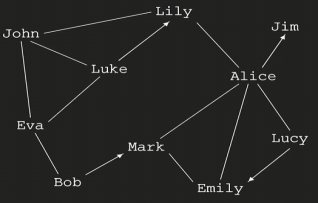

And in this particular example, the graph would be undirected because a friendship is a mutual connection. But in some other scenarios, our graph might become directed in an app like Twitter, for instance, it's possible for Bob to follow Mark, but Mark to not follow him back. So this action would only go one way. Therefore the edge would be directed

Network meshes are another example where graphs are used. An IT infrastructure can be modeled with computers as the vertices and the connections between them as the edges. Mesh networks and the algorithms that govern them can become extremely complicated, allowing them to self-configure, self-organize, and heal broken paths

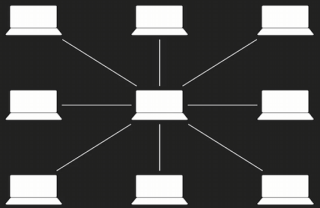

And lastly, one of the most complex real world applications for graph theory is the GPS system. The streets and roads of a certain area are represented by a network of vertices and edges, and whenever we want to travel from one place to another, there is an algorithm that calculates the directions to our destination. This means that the graph will have to be weighted with edges having multiple values assigned to them, like the distance or the travel time for driving, cycling, and walking. These values will all be computed and added together to give us the fastest or the shortest route. And we already mentioned the one way streets, which also have to be accounted for and represented as a directed edge.

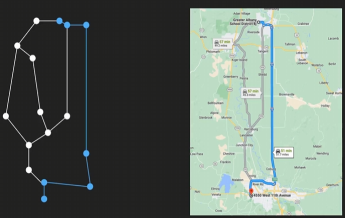

Out of all the graph variations we just saw, the one that we will study in this section will be the simple undirected graph. We will allow only one edge between the same nodes. We won't have any weighted edges, and all the connections between the nodes will be undirected. The algorithms will learn in this section will therefore be tailored to this type of graph

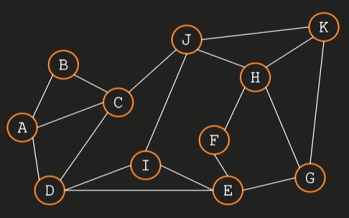

Okay, so how do we represent such a thing in code? What kind of structure can be used to represent all these connections? We can't really do it with node classes like we did with everything else, because with those structures, we knew exactly the maximum number of connections a node can have. Here we don't have a limit, so we don't know how many properties our class should have. So we need to find an alternative solution. And there are in fact a couple of options we can choose from

One of them is called the **Adjacency list**. This will be a Python dictionary where we store all the vertices as keys and a list of edges as the values.

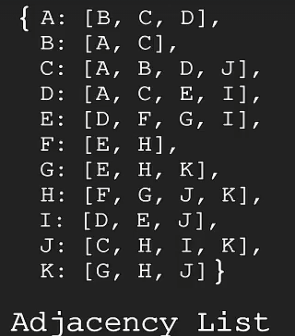

So for example, we can see here that the key `A` represents the vertex with the same name, and the value of this key is a list of all the other vertices `A` is connected to… `B`, `C`, and `D`, and all the other connections are represented the same way. The vertex is the key and the list of edges as the value.

Another way of storing this graph is with a matrix which comes in two forms an **Adjacency matrix** and an **Incidence matrix**.

**Adjacency matrix**

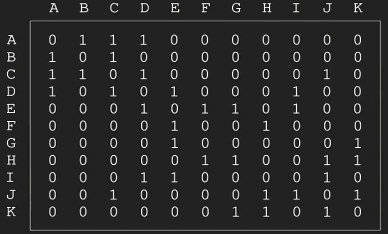
  

The adjacency matrix is a table where both the rows and the columns represent the vertices. The values inside the matrix are ones and zeros that tell us whether the two intersecting vertices have a connection or not.

**Incidence matrix**

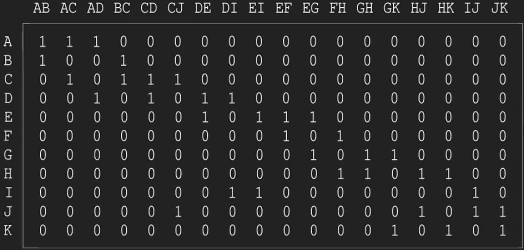

The incidence matrix is similar to the adjacency one, in the sense that it will also be a binary matrix with only ones and zeros, but this time the rows will represent the vertices and the columns will be the edges.

As always, one implementation is not necessarily better than the other. It all depends on the problem at hand. 
The adjacency list is better at adding new vertices and edges, since adding new keys to a dictionary is a constant time operation. On the other hand, it's a bit slower at removing vertices and edges since it needs to iterate over the lists. The adjacency list is usually preferred when the graph is sparse, meaning we don't have that many edges. 

The matrix representation is good at processing edges, because that would mean to simply change a one into a zero or vice versa. Adding or removing vertices, on the other hand, is more time consuming because the matrix will need to be resized. This implementation is preferred when the graph is more dense, or when we need to do a lot of work with the edges
The one we will use in this session is the adjacency list. I think it's the one you're most likely to encounter and it's easier to work with

### Adding Vertices and Edges

We start off with how to add new vertices and edges. So this is the graph we have now with vertices from A to K. And let's say we want to add L to that and connect it to B and J. The first step we need to take would be to add L to the graph. This operation is as simple as adding a new key to a dictionary. So in our graph we have here, we just need to create a new key called L. And then the value of this key will be an empty list where the edges will go

e.g  L : [ ] 

**Before**

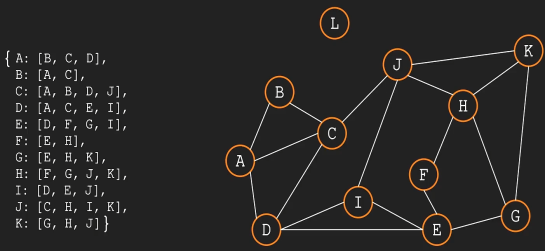

And that would be enough to add L to the graph, but it doesn't have any connections. To create one with the vertex B, we need to add B to L's list of edges, but also go to B's list and add to it. Because remember our graph is undirected. Every connection between two nodes needs to be mutual. Adding an edge between L and J will be done the exact same way.

**After Adding** : pls refer to list L,B & J for updated vertices

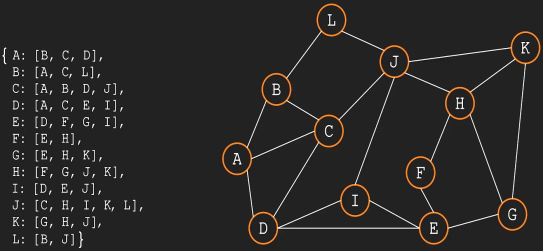

We add L to B's list and then go to J's list and add L to it. It's as simple as that. So when coding these two steps, we have to create two separate functions one that handles adding the vertex to the graph and one that handles adding edges between vertices. We separate the two operations because there might be situations where we want to add edges without having to add a vertex.

And one more thing ,our implementation enforces uniqueness of vertices, meaning we won't allow adding a vertex that is already in the graph. We can just throw an error when that happens. This is a thing to consider when coding these methods


In [63]:
''' Initialization '''
class Graph:
    def __init__(self):
        self.adjacency_list = {}
# Creating an empty dictionary (instead of list) to hold graph's vertices as keys, and their neighbors (adjacent vertices) as values.
    ''' Adding a Vertex '''
    def add_vertex(self, vertex):
        if vertex in self.adjacency_list: # checking if that person (vertex) is already in your address book (dictionary).
            raise Exception ("Vertex already in graph") 
        self.adjacency_list[vertex] = [] # If they’re not, you add them and associate an empty list, which will later be filled with their connections.
        return self
# e.g self.adjacency_list["Alice"] = [] means Alice is now part of the graph, but has no connections yet.
# {} holds pairs → vertex: [list of neighbors] & [] is the list of neighbors for each vertex
# Think of it like this: you're building a phonebook where each person (vertex) has a list of contacts (adjacent vertices). 
# The phonebook itself is a dictionary, but each person’s contact list is a list.
    ''' Adding an Edge '''    
    def add_edge(self, vertex1, vertex2): # since its undirected graph, we are looking for handshake from both parties
        if vertex1 not in self.adjacency_list or vertex2 not in self.adjacency_list:
            raise Exception ("Invalid vertices") # First, you're verifying that both people already exist in the graph.
        self.adjacency_list[vertex1].append(vertex2) # Second you're updating each person’s list of friends to include the other.
        self.adjacency_list[vertex2].append(vertex1)
        return self
# we could combine these two functions(add vertex & edge) into a single one where we both add a new vertex and all its edges. 
# But we would still need a separate add edge method for when we need to just add a new edge without a vertex.

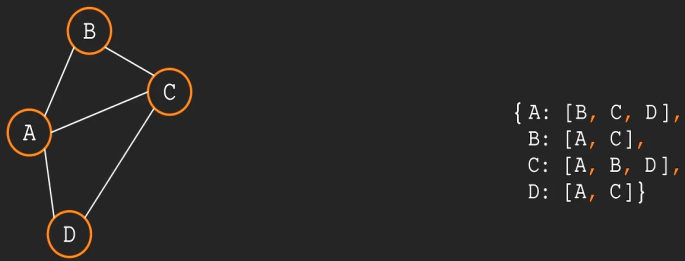

In [84]:
pp=Graph()

In [86]:
pp.add_vertex("A")
pp.add_vertex("B")
pp.add_vertex("C")
pp.add_vertex("D")

In [88]:
pp.add_edge("A", "B")
pp.add_edge("A", "C")
pp.add_edge("A", "D")
pp.add_edge("B", "C")
pp.add_edge("C", "D")

In [94]:
print(pp.adjacency_list)

{'A': ['B', 'C', 'D'], 'B': ['A', 'C'], 'C': ['A', 'B', 'D'], 'D': ['A', 'C']}


#### Time And Space Complexity

When we learned about dictionaries, we said that adding a new key is done in constant time. Add vertex does just that. It only adds a new key to the adjacency list, so both the time and space complexity for the first method is O(1).
Add Edge does two operations to list appends, both of which are also constant time. Adding to the end of a list is considered an O(1) action. And this is exactly what we do here. So both our operations of adding vertices and edges perform as best as possible in the adjacency list implementation.


##### Time :  *O* (1)
##### Space : *O* (1)

### Removing Vertices and Edges

We're now going to see how we can remove edges and vertices from our graph. And we start with the easier one, which is removing an edge. When we added a new edge between two vertices, we just appended each of those vertices to the other ones. List of edges. The process of removing an edge is essentially the reverse of that

Let's say we want to **remove the edge** between `G` and `H`. To do that, we just need to go to `G's` list of edges and remove `H` from it. And then go to `H's` list and remove `G`. And that's it. It's as simple as that. The connection between the two vertices is now gone. Any edge in the graph can be removed in those two steps

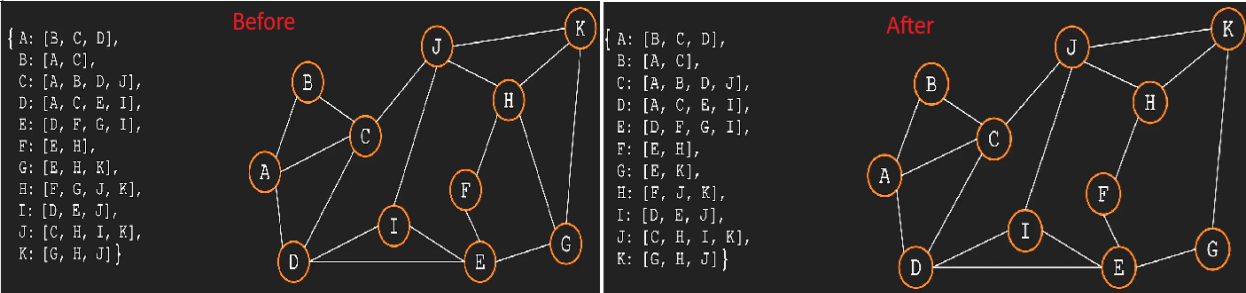

Okay, so let's now see how we can **remove a vertex**. This takes a bit more logic because we can't just remove the key value pair of that vertex. We'll still have references to that vertex in the lists of all the other vertices it's connected to. Let's take C as an example to illustrate what I mean. If we just remove the key C from our dictionary, along with its list of edges, that will indeed remove the vertex from the graph, but we still have it referenced in the lists of edges for all the other vertices it was connected to. And we end up with the edges that start at A and B, for example But don't go anywhere since we removed C, we need to fix that by removing C from all these lists

And how do we do that? Well with the way we have our adjacency list right now, that would require a brute force approach where we would check all the lists for any occurrence of C, but that is terribly inefficient. It would be better if we had a list of all the connections of C to other vertices. We used to have that, but we removed it along with the vertex C. Our logic will therefore have to be a bit modified.

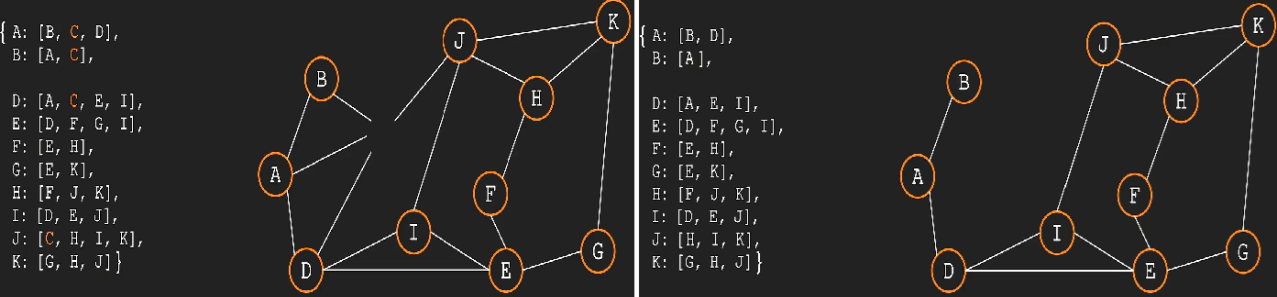

So let's bring back C and its list of vertices to see how it's done 

**C : [ A, B, D, J ]**


We start by iterating over `C's` list of edges. The first one is `A`, so we go to `A's` list of edges and remove `C` from it. After that we go to the next vertex in `C's` list, which is `B`. We go to its list of edges, find `C` in it, and then remove it. Moving on to `D`. Remove `C` from its list and then finally do the same thing to `J`. After we finish iterating over all the vertices in `C's` list, we can finally remove it along with the vertex itself, and that will completely remove both the vertex and all its connections it had in the graph. So this is how the methods of removing edges and vertices will look like


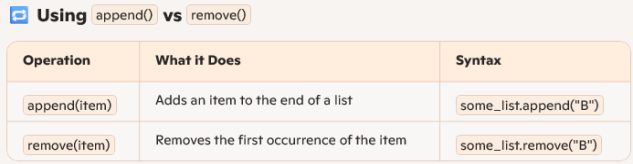

**Let’s explore how edges behave differently in a graph versus a binary tree**

**In Binary Trees**
  - When you remove a node from a binary tree, you also automatically remove the edges connected to it—because edges aren’t stored separately.
  - Each node “knows” its children through references like .left and .right, so deleting the node also cuts off its connections.

**In Graphs (Adjacency List Style)**
  - Edges are implicitly stored in the adjacency lists of the vertices.
  - So, when you remove a vertex (like "C"), the edges connected to "C" don’t automatically disappear unless you explicitly remove the references from every other vertex’s list.

That’s why this step is crucial:

This cleans up the edges manually, because graphs don’t track edges as independent objects—they’re just lists tucked into each vertex’s dictionary entry.

In [33]:
''' Initialization '''
class Graph:
    def __init__(self):
        self.adjacency_list = {}
# Creating an empty dictionary (instead of list) to hold graph's vertices as keys, and their neighbors (adjacent vertices) as values.
    ''' Adding a Vertex '''
    def add_vertex(self, vertex):
        if vertex in self.adjacency_list: # checking if that person (vertex) is already in your address book (dictionary).
            raise Exception ("Vertex already in graph") 
        self.adjacency_list[vertex] = [] # If they’re not, you add them and associate an empty list, which will later be filled with their connections.
        return self
# e.g self.adjacency_list["Alice"] = [] means Alice is now part of the graph, but has no connections yet.
# {} holds pairs → vertex: [list of neighbors] & [] is the list of neighbors for each vertex
# Think of it like this: you're building a phonebook where each person (vertex) has a list of contacts (adjacent vertices). 
# The phonebook itself is a dictionary, but each person’s contact list is a list.
    ''' Adding an Edge '''    
    def add_edge(self, vertex1, vertex2): # since its undirected graph, we are looking for handshake from both parties
        if vertex1 not in self.adjacency_list or vertex2 not in self.adjacency_list:
            raise Exception ("Invalid vertices") # First, you're verifying that both people already exist in the graph.
        self.adjacency_list[vertex1].append(vertex2) # Second you're updating each person’s list of friends to include the other.
        self.adjacency_list[vertex2].append(vertex1)
        return self
# we could combine these two functions(add vertex & edge) into a single one where we both add a new vertex and all its edges. 
# But we would still need a separate add edge method for when we need to just add a new edge without a vertex.

    ''' Removing an Edge '''    
    def remove_edge(self, vertex1, vertex2): # since its undirected graph, we are looking for handshake from both parties, unlike in directed graph
    # If "V2" isn't in "V1"'s list when you call remove("V2"), Python will throw a ValueError.So it's good to check if the edge exists before proceeding
        if vertex1 not in self.adjacency_list or vertex2 not in self.adjacency_list:
            raise Exception ("Invalid vertices") # First, you're verifying that both people already exist in the graph.
        self.adjacency_list[vertex1].remove(vertex2) # Second, you're removing entries from each other 
        self.adjacency_list[vertex2].remove(vertex1)
        return self
    
    ''' Removing a Vertex '''    
    def remove_vertex(self, vertex): # Lets say the vertex we are trying to remove here is C
        if vertex not in self.adjacency_list:# checks in the dictionary if Vertex C is listed/available before we proceed with removing its connection
            raise Exception ("Vertex not in graph")
        for neighbor in self.adjacency_list[vertex]: # Goes thru each of the vertices listed under C which is C: [ A, B, D, J ]
            self.adjacency_list[neighbor].remove(vertex)# e.g visits A and removes C from its list, then loops again to visit B, then D & finally J
        self.adjacency_list.pop(vertex) # Once C is removed from A,B,D & J, we now proceed to remove the node C completely along with edges since in graphs,
        return self #  the nodes wont disappear when edges are removed (unlike in Binary Trees), here we have to explicity remove the node.
        
    ''' For Printing output in horizontal fashion'''
    def print_graph(self):
        for vertices,edges in self.adjacency_list.items():
            print(f"{vertices}:{edges}")

**Important**

If you manually call remove_edge(c, a), remove_edge(c, b), remove_edge(c, d), remove_edge(c, j), then all traces of C in other vertices are already gone. That leaves you with

**C : [ ]**

So why does remove_vertex() still have that loop?

**The Design Difference**
- Your manual approach:
You’re explicitly removing every edge connected to `C` one by one. By the time you finish, no other vertex lists `C`. At that point, you could safely just do `self.adjacency_list.pop("C")` and be done.
- The `remove_vertex()` method:
It’s written to handle the general case where you haven’t already removed all those edges manually. It automates the cleanup step:

for neighbor in self.adjacency_list[vertex]:
    self.adjacency_list[neighbor].remove(vertex)

ensures that every neighbor of `C` drops its reference to `C` in one sweep. Then `pop("C")` deletes the entry itself.

**Why Both Exist**
 - `remove_edge()`is surgical — you use it when you want to remove one specific connection.
 - `remove_vertex()`is holistic — it assumes you haven’t already cleaned up edges, so it does that for you before deleting the vertex.

**Why use `pop()` & not `remove()` to delete Vertex `C`?**

1. `remove()` works on `Lists`
2. `pop()` Works on `lists` and `dictionaries`, but behaves differently:
    - On a list, pop(index) removes by position (default is the last element).
    - On a dictionary, pop(key) removes the key-value pair entirely.

In [183]:
# List example
my_list = [1, 2, 3]
my_list.remove(2)   # removes the value 2
my_list

[1, 3]

In [185]:
# Dictionary example
my_dict = {"A": [1, 2], "B": [3, 4]}
my_dict.pop("A")   # removes the key "A" and its list
my_dict

{'B': [3, 4]}

In [187]:
# when used in list, pop() will delete from right but when we use remove() -> error : list.remove() takes exactly one argument (0 given)
my_list = [1, 2, 3]
my_list.pop()

3

In [189]:
# same with Dictionary my_dict.pop("A") will delete Vertex A,  but my_dict.pop() -> Error : pop expected at least 1 argument, got 0
my_dict = {"A": [1, 2], "B": [3, 4]}
#my_dict.pop() 

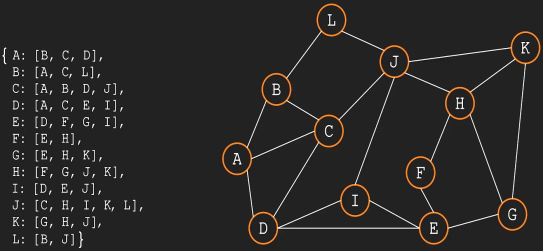

In [268]:
# Now lets create above graph using Add & Remove Vertics/Edges
graph=Graph()

In [270]:
# add vertex using method chaining
graph.add_vertex("A").add_vertex("B").add_vertex("C").add_vertex("D").add_vertex("E").add_vertex("F").add_vertex("G").add_vertex("H").add_vertex("I").add_vertex("J").add_vertex("K").add_vertex("L")

In [250]:
print(graph.adjacency_list)

{'A': [], 'B': [], 'C': [], 'D': [], 'E': [], 'F': [], 'G': [], 'H': [], 'I': [], 'J': [], 'K': [], 'L': []}


In [272]:
# Now lets add vertices inline with above snapshot
graph.add_edge("A","B").add_edge("A","D").add_edge("A","C").add_edge("B","C").add_edge("B","L").add_edge("C","D").add_edge("C","J").add_edge("J","L").add_edge("J","I").add_edge("K","J").add_edge("I","D").add_edge("I","E").add_edge("H","F").add_edge("H","G").add_edge("F","E").add_edge("E","G").add_edge("D","E").add_edge("G","K").add_edge("H","K").add_edge("H","J")
print(graph.adjacency_list)

{'A': ['B', 'D', 'C'], 'B': ['A', 'C', 'L'], 'C': ['A', 'B', 'D', 'J'], 'D': ['A', 'C', 'I', 'E'], 'E': ['I', 'F', 'G', 'D'], 'F': ['H', 'E'], 'G': ['H', 'E', 'K'], 'H': ['F', 'G', 'K', 'J'], 'I': ['J', 'D', 'E'], 'J': ['C', 'L', 'I', 'K', 'H'], 'K': ['J', 'G', 'H'], 'L': ['B', 'J']}


In [254]:
# Lets use the same method outside the class, without using self 
def print_graph2(graph):
    for vertices,edges in graph.adjacency_list.items():# replacing self.adjacency_list with graph.adjacency_list, since its created outside "graph"class
        print(f"{vertices}:{edges}")

In [256]:
# Printing output using method(print_graph) which was created inside the class(Graph)
graph.print_graph()

A:['B', 'D', 'C']
B:['A', 'C', 'L']
C:['A', 'B', 'D', 'J']
D:['A', 'C', 'I', 'E']
E:['I', 'F', 'G', 'D']
F:['H', 'E']
G:['H', 'E', 'K']
H:['F', 'G', 'K', 'J']
I:['J', 'D', 'E']
J:['C', 'L', 'I', 'K', 'H']
K:['J', 'G', 'H']
L:['B', 'J']


In [258]:
# Printing output without using "self" ,since it was created outside the class(Graph)
print_graph2(graph)

A:['B', 'D', 'C']
B:['A', 'C', 'L']
C:['A', 'B', 'D', 'J']
D:['A', 'C', 'I', 'E']
E:['I', 'F', 'G', 'D']
F:['H', 'E']
G:['H', 'E', 'K']
H:['F', 'G', 'K', 'J']
I:['J', 'D', 'E']
J:['C', 'L', 'I', 'K', 'H']
K:['J', 'G', 'H']
L:['B', 'J']


In [260]:
# Now lets use the remove method to remove vertex "C" from the class "Graph"
graph.remove_edge("C","A").remove_edge("C","B").remove_edge("C","D").remove_edge("C","J")

In [264]:
# All traces of vertex "C" is removed from all linked vertices and Vertex "C" is Empty now
graph.print_graph()

A:['B', 'D']
B:['A', 'L']
C:[]
D:['A', 'I', 'E']
E:['I', 'F', 'G', 'D']
F:['H', 'E']
G:['H', 'E', 'K']
H:['F', 'G', 'K', 'J']
I:['J', 'D', 'E']
J:['L', 'I', 'K', 'H']
K:['J', 'G', 'H']
L:['B', 'J']


In [274]:
# Now we will add the vertex "C" again and print the output to confirm "C" is back in graph 
graph.print_graph()

A:['B', 'D', 'C']
B:['A', 'C', 'L']
C:['A', 'B', 'D', 'J']
D:['A', 'C', 'I', 'E']
E:['I', 'F', 'G', 'D']
F:['H', 'E']
G:['H', 'E', 'K']
H:['F', 'G', 'K', 'J']
I:['J', 'D', 'E']
J:['C', 'L', 'I', 'K', 'H']
K:['J', 'G', 'H']
L:['B', 'J']


In [276]:
# Now we will use "remove_vertex" method to confirm if all the edges & vertex of "C" is removed without executing "remove_edge"
graph.remove_vertex("C")

In [280]:
# All instances of "C" is indeed eliminated including the Vertex"C". Also discussed "remove_edge" has added step to remove edges apart from Vertex
graph.print_graph()

A:['B', 'D']
B:['A', 'L']
D:['A', 'I', 'E']
E:['I', 'F', 'G', 'D']
F:['H', 'E']
G:['H', 'E', 'K']
H:['F', 'G', 'K', 'J']
I:['J', 'D', 'E']
J:['L', 'I', 'K', 'H']
K:['J', 'G', 'H']
L:['B', 'J']


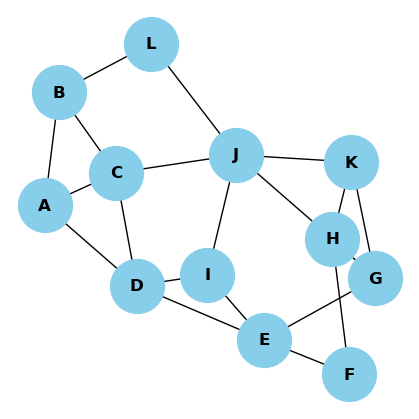

In [314]:
# Plotting actual graph using vertices & edges with help from graph visualization libraries like NetworkX and Matplotlib 
import networkx as nx
import matplotlib.pyplot as plt

# Your adjacency list
adjacency_list = {
    "A": ["B", "C", "D"],
    "B": ["A", "C", "L"],
    "C": ["A", "B", "D", "J"],
    "D": ["A", "C", "E", "I"],
    "E": ["D", "F", "G", "I"],
    "F": ["E", "H"],
    "G": ["E", "H", "K"],
    "H": ["F", "G", "J", "K"],
    "I": ["D", "E", "J"],
    "J": ["C", "H", "I", "K", "L"],
    "K": ["G", "H", "J"],
    "L": ["B", "J"]
}

# Create a graph object
G = nx.Graph()

# Add edges from adjacency list
for vertex, neighbors in adjacency_list.items():
    for neighbor in neighbors:
        G.add_edge(vertex, neighbor)

# Draw the graph
plt.figure(figsize=(4, 4))
nx.draw(G, with_labels=True, node_color="skyblue", node_size=1500, font_size=12, font_weight="bold")
plt.show()

#### Time And Space Complexity

So, let's now have a look at the complexities of these methods. When talking about the big O of graph operations, we need to consider the type of implementation we chose. We will have different performances depending on whether we used an adjacency list or a matrix. We also need to be careful with terminology and notation. Sometimes people refer to edges as the total number of edges in the graph, sometimes only to the edges of one particular vertex, and that can cause confusion. 

So, keeping that in mind, let's think about the complexity of remove edge. What we do inside this function is we remove two elements from two different lists. This remove method is of O(n) complexity, because we can potentially iterate over all the elements of the list until we find the one that we want to remove. And as we already know, having two of these methods doesn't change the fact that the final complexity is still O(n), now because the elements now lists are basically vertices. The complexity of this method is normally written as O(V), and that's how we will write it as well. The space complexity is O(1), since we don't use any additional memory when running this method. So that was remove edge. 

**Remove Edge**
##### Time :  *O* (V)
##### Space : *O* (1)

Let's now turn our attention to remove vertex. Here we also apply the remove method on some lists, but this time not only twice. In the worst-case scenario, the vertex we have to remove is connected to all the other ones in the graph. This means that we have to iterate over all the other lists of edges, and the total number of elements we have to iterate over is actually equal to the total number of edges in the graph. The standard notation for all the edges in the graph is **E**, so we can say that the time complexity of removing a vertex is O(E). The other operation we do inside this function at the codeline (.pop(vertex)) is an O(1) operation. Removing a key from a dictionary is constant time, so that doesn't affect in any way the final complexity. 

**Remove Vertex**
##### Time :  *O* (E)
##### Space : *O* (1)

### Breadth First Traversal

Traversing is a process of visiting every vertex only one time. And given the fact that graphs are a generalization of trees, the logic of traversing a graph will be, at its core, very similar to the one we used on trees. The algorithms even have the same names. Breadth first and depth first. And here we will learn how the breadth first traversal works on graphs.

Recall that with trees, traversing breadth first meant visiting nodes level by level. We started at the top and we moved down only after all the nodes at the current level were visited. Since these methods share the same name, this means that we could traverse our graph by applying the same principle, right? But if we have a look at our graph, we see a couple of issues.


First of all, where do we start? With trees we only had one entry point the root. But with graphs there is no starting node. Even though we might consider a as the first node because it's the first one we added to the graph, let's not forget that the graph is stored as a dictionary. An element in a dictionary is not ordered in any way. The answer for this question is pretty simple though. If we can access every vertex from the graph equally as fast. This means that our solution should be able to start at any vertex and work the same.


The second question, and probably the harder one, is how exactly do we know which vertices are on the same level? With trees, it was pretty easy to see that we just followed the hierarchy. But with graphs it's not that simple. To answer this, we need to look at the tree traversal from a different perspective. Instead of thinking that we traverse the tree from top to bottom, we need to realize that with each level, we traverse the children of all the nodes from the previous level. After we visited it, we then visited all its children, which were `15` and `44` before moving down. And only when we're done with those, we move to the direct children of `15` and `44` and visit all of them, and so on.

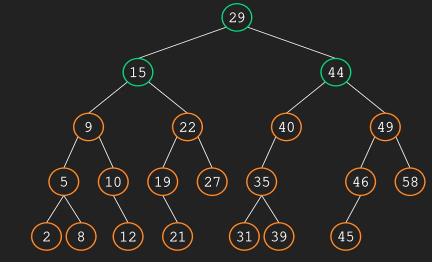

We can therefore apply the same logic when traversing a graph.

If we start, for example, at vertex A and we visit it, the next level, so to speak, would be the vertices that `A` is directly connected to. We can't call them children because in a graph they're not considered as such since there is no hierarchy. 

So the next vertices to be visited will be `B`, `C` and `D`. After that, we need to visit the vertices that are directly connected to these three we last visited. `B` is directly connected to `A` and `C`, but we've already visited them, so we move on to the next one. `C` is connected to `A`, `B`, `D`, and `J`. Out of all of them, `J` is the only one not visited, so we go ahead and visit it. The last one of them would be `D`. The vertices that are connected to `D` but are not yet visited are `E` and `I`. So go ahead and visit them. And then we just repeat the same steps. The last nodes visited were `J`, `I` and `E`. We need to go to all the direct connections of these three and visit whichever are not yet visited. For `J` that would be `H` and `K`. For `I` we don't have any unvisited direct connections, since both `J` and `D` were visited in previous iterations. And for `E` that would be `F` and `G`. And as you can see, we've just visited the entire graph. Of course, the algorithm will not know this in advance like we do, and will try to verify all the other vertices and their children like `H`, `K`, or `G`. But when it stops, all the vertices will be visited.

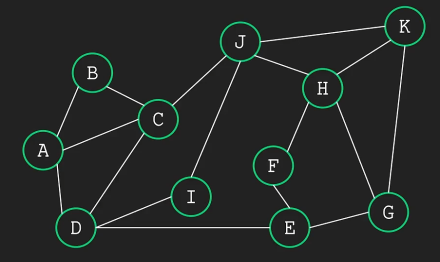

So when we did this method for trees, we needed a container to store the nodes that would be next in line to be visited. And for that we used a queue.. But because in a graph, there's a high chance for us to reach a node we already visited, we need to find a way to mark the vertices to avoid revisiting them. And I don't mean to mark them as visited, because remember, visiting a node can mean anything, and we don't always visit a node by adding it to a list. We need a separate way of marking the nodes we added at some point to the queue, and we do that by using another container, like a list or a dictionary. 

A list is a simpler implementation, but worse in terms of performance, so we will use a dictionary to mark the vertices as we explore them

#### Data Structure Comparison in Python

| Operation        | **List**                          | **Set**                           | **Dict** (key → value)            |
|------------------|-----------------------------------|-----------------------------------|-----------------------------------|
| **Access**       | `O(1)` by index, `O(n)` by value | `O(1)` average (hash lookup)      | `O(1)` average (hash lookup by key) |
| **Insertion**    | `O(1)` at end, `O(n)` at front   | `O(1)` average                    | `O(1)` average (assign new key)   |
| **Removal**      | `O(1)` at end, `O(n)` by value   | `O(1)` average                    | `O(1)` average (delete by key)    |
| **Duplicates**   | Allowed                          | Not allowed                       | Keys unique, values can repeat    |
| **Ordering**     | Preserves order (Python ≥3.7)    | No guaranteed order (though stable in CPython ≥3.7) | Preserves insertion order (Python ≥3.7) |
| **Use case**     | Sequential data, ordered lists   | Membership tests, uniqueness      | Key-value mapping, fast lookups   |

**Why this matters for Graph Traversal**
- **List** : Good for storing traversal order (`visited = []`), but slow for membership checks (`if v in visited` → `O(n)`).
- **Set** : Great for fast membership checks (`O(1)`), but doesn’t store extra info beyond presence/absence.
- **Dict** : Best when you need to track state per vertex (like `True/False`, distances, parent pointers). That’s why `{vertex: False}` is used — it maps each vertex directly to its visited status.


In [332]:
def breadth_first_traversal(self, start): # You can start with any vertices .e.g E from where the traversal should begin
    ''' Vertex presence check '''
    if start not in self.adjacency_list: # Ensures the graph contains the start vertex.If not found, it raises a clear exception to avoid invalid access.
        raise Exception ("Vertex not in graph")
# we needed a container to store the nodes that would be next in line to be visited.And for that we used a queue,creating an empty double-ended queue
# (a deque)from the collections module.It allows fast appends & pops from both the front and the back.It's much more efficient than using a list when 
# doing repeated insertions/removals from the front(like in BFS),we are initializing the queue that will be used in the Breadth-First Search (BFS) 
# traversal of the graph.It's where nodes are temporarily stored (for processing) until it's their turn to be visited
    ''' Initialize queue and visited list '''
    queue = deque() # queue stores vertices to process next (BFT uses FIFO).so we can later down the code use pop function on queue to traverse the graph
    queue.append(start) # start is the first to be visited, so it's queued
    visited = [] # keeps track of the order in which nodes are processed and returned at the end of the loop
    ''' Initialize exploration status '''
    explored = {vertex : False for vertex in self.adjacency_list} # each vertices in adjacency_list is marked as false,so when vertice is visited , its
# converted to True for tracking purpose  e.g explored :{ A:False,B:False,C:False,D:False,E:False,F:False,G:False,H:False,I:False,J:False,K:False,}

# explored = {} -this is how regular code looks like,above we have used dictionary comprehension which is a concise & readable way to create dictionaries
# for vertex in self.adjacency_list:
#    explored[vertex] : False -  The colon (:) is simply the Dictionary syntax that binds them together.
    explored[start] = True # E : True
    ''' Main BFT loop '''
    while queue: # Continues until there are no more nodes to explore.
        current = queue.popleft() # Removes the front element (current) from the queue (FIFO behavior).First E is popped 
        visited.append(current) # popped node is added to current to pull up its adjacent neighbors,once E is popped, we get D,F & G (left to right)
        ''' Explore adjacent vertices'''       
        for adjacent in self.adjacency_list[current]: # when while loop restarts D is popped & we get A,C,I and so on
            if not explored[adjacent]:
# if we had choosen list instead of dictionary to search for vertices & marking them as explored,the complexity would have been O(n).With dictionary 
# we have instant access to all keys, making this if clause O(1) operation & thats why dictionary was choosen '''
                queue.append(adjacent)#if choosen node is False,we append it to Queue,if True we skip next code,go back to For loop & check next neighbor
                explored[adjacent] = True # and mark it as true, so we dont double count it or duplicate in queue
    return visited

In [ ]:
# Lets execute BFT algorithm from start to end

from collections import deque # if you dont import deque from collections, you will get the error "name 'deque' is not defined"

''' Initialization '''
class Graph:
    def __init__(self): 
        self.adjacency_list = {} # Instance
# Creating an empty dictionary (instead of list) to hold graph's vertices as keys, and their neighbors (adjacent vertices) as values.
    ''' Adding a Vertex '''
    def add_vertex(self, vertex): # methods
        if vertex in self.adjacency_list: # checking if that person (vertex) is already in your address book (dictionary).
            raise Exception ("Vertex already in graph") 
        self.adjacency_list[vertex] = [] # If they’re not, you add them and associate an empty list, which will later be filled with their connections.
        return self
# e.g self.adjacency_list["Alice"] = [] means Alice is now part of the graph, but has no connections yet.
# {} holds pairs → vertex: [list of neighbors] & [] is the list of neighbors for each vertex
# Think of it like this: you're building a phonebook where each person (vertex) has a list of contacts (adjacent vertices). 
# The phonebook itself is a dictionary, but each person’s contact list is a list.
    ''' Adding an Edge '''    
    def add_edge(self, vertex1, vertex2): # since its undirected graph, we are looking for handshake from both parties
        if vertex1 not in self.adjacency_list or vertex2 not in self.adjacency_list:
            raise Exception ("Invalid vertices") # First, you're verifying that both people already exist in the graph.
        self.adjacency_list[vertex1].append(vertex2) # Second you're updating each person’s list of friends to include the other.
        self.adjacency_list[vertex2].append(vertex1)
        return self

# if you try to run below function it wont work unless you define it as a class method right under the main class (Graph) like we have done here
    def breadth_first_traversal(self, start): # You can start with any vertices .e.g E from where the traversal should begin
        ''' Vertex presence check '''
        if start not in self.adjacency_list: # Ensures the graph contains the start vertex.If not found, it raises a clear exception to avoid invalid access.
            raise Exception ("Vertex not in graph")
    # we needed a container to store the nodes that would be next in line to be visited.And for that we used a queue,creating an empty double-ended queue
    # (a deque)from the collections module.It allows fast appends & pops from both the front and the back.It's much more efficient than using a list when 
    # doing repeated insertions/removals from the front(like in BFS),we are initializing the queue that will be used in the Breadth-First Search (BFS) 
    # traversal of the graph.It's where nodes are temporarily stored (for processing) until it's their turn to be visited
        ''' Initialize queue and visited list '''
        queue = deque() # queue stores vertices to process next (BFT uses FIFO).so we can later down the code use pop function on queue to traverse the graph
        queue.append(start) # start is the first to be visited, so it's queued
        visited = [] # keeps track of the order in which nodes are processed and returned at the end of the loop
        ''' Initialize exploration status '''
        explored = {vertex : False for vertex in self.adjacency_list} # each vertices in adjacency_list is marked as false,so when vertice is visited , its
    # converted to True for tracking purpose  e.g explored :{ A:False,B:False,C:False,D:False,E:False,F:False,G:False,H:False,I:False,J:False,K:False,}
    
    # explored = {} -this is how regular code looks like,above we have used dictionary comprehension which is a concise & readable way to create dictionaries
    # for vertex in self.adjacency_list:
    #    explored[vertex] : False -  The colon (:) is simply the Dictionary syntax that binds them together.
        explored[start] = True # E : True
        ''' Main BFT loop '''
        while queue: # Continues until there are no more nodes to explore.
            current = queue.popleft() # Removes the front element (current) from the queue (FIFO behavior).First E is popped 
            visited.append(current) # popped node is added to current to pull up its adjacent neighbors,once E is popped, we get D,F & G (left to right)
            ''' Explore adjacent vertices'''       
            for adjacent in self.adjacency_list[current]: # when while loop restarts D is popped & we get A,C,I and so on
                if not explored[adjacent]:
    # if we had choosen list instead of dictionary to search for vertices & marking them as explored,the complexity would have been O(n).With dictionary 
    # we have instant access to all keys, making this if clause O(1) operation & thats why dictionary was choosen '''
                    queue.append(adjacent)#if choosen node is False,we append it to Queue,if True we skip next code,go back to For loop & check next neighbor
                    explored[adjacent] = True # and mark it as true, so we dont double count it or duplicate in queue
        return visited

In [111]:
# First creating an instance of the class
graph = Graph()

In [113]:
# Now you will be able to see methods and function under graph,when you type graph. & press tab... You will now see "breadth_first_traversal" as function
# Lets update the adjacency_list by adding the vertices first and then the edges
graph.add_vertex("A").add_vertex("B").add_vertex("C").add_vertex("D").add_vertex("E").add_vertex("F").add_vertex("G").add_vertex("H").add_vertex("I").add_vertex("J").add_vertex("K")

In [115]:
# Now adding the edges and displaying the adjacency list 
graph.add_edge("A","B").add_edge("A","D").add_edge("A","C").add_edge("B","C").add_edge("C","D").add_edge("C","J").add_edge("J","I").add_edge("K","J").add_edge("I","D").add_edge("H","F").add_edge("H","G").add_edge("F","E").add_edge("E","G").add_edge("D","E").add_edge("G","K").add_edge("H","K").add_edge("H","J")
print(graph.adjacency_list)


{'A': ['B', 'D', 'C'], 'B': ['A', 'C'], 'C': ['A', 'B', 'D', 'J'], 'D': ['A', 'C', 'I', 'E'], 'E': ['F', 'G', 'D'], 'F': ['H', 'E'], 'G': ['H', 'E', 'K'], 'H': ['F', 'G', 'K', 'J'], 'I': ['J', 'D'], 'J': ['C', 'I', 'K', 'H'], 'K': ['J', 'G', 'H']}


In [117]:
# And nowwe finally call the BFT function and get the output by assigning E as start
graph.breadth_first_traversal("E")

['E', 'F', 'G', 'D', 'H', 'K', 'A', 'C', 'I', 'J', 'B']

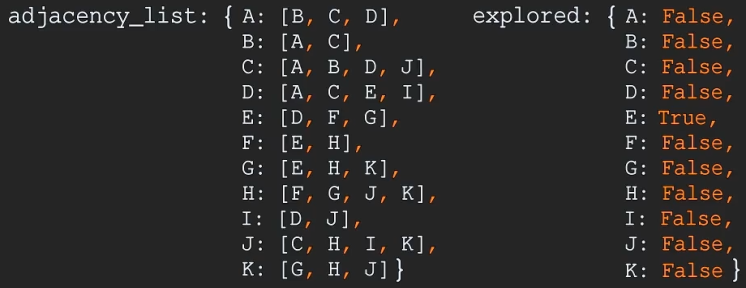

**Why not just use a list?**
- A list like visited = [ ] only stores the order of traversal.
- But checking membership (if v in visited) is `O(n)`, which is slower for large graphs.
- The dictionary approach (explored[v]) is `O(1)`, much faster and more efficient.

If you only used a list like [False, False, False, False], you’d lose the direct mapping. 

You’d have to remember which index corresponds to which vertex. With a dictionary, you can directly say:

**explored ['C']**

instead of figuring out “C is index 2 in the list.


**Why use vertex : value**
- In Python dictionaries, every entry is a key-value pair.
- The key `(vertex)` identifies the item uniquely.
- The value `(False)` stores the state or data associated with that key.
- The colon `(:)` is simply the syntax that binds them together.

Think of it like a label and its status:
- "Door": Locked
- "Light": Off
- "Vertex A": False




**Why BFS applies to graphs too**
- **Concept of “breadth”**: In trees, BFS is often described as level-order traversal (visit all nodes at depth 1, then depth 2, etc.).
- **Graphs don’t have levels** in the same sense, but BFS still explores nodes in waves of distance from the starting vertex:
- First, it visits all neighbors at distance 1.
- Then all vertices at distance 2.
- Then distance 3, and so on.
- So instead of “levels,” BFS in graphs is based on **shortest path distance from the start node.**


**Key distinction**
- **Tree BFS** → naturally aligned with levels (root → children → grandchildren).
- **Graph BFS** → aligned with layers of distance from the source vertex.
That’s why BFS is so powerful in graphs: it guarantees that when you first reach a vertex, you’ve found the shortest path (in terms of edge count) from the start..




**Why we still call it BFT**

The name comes from the **order of exploration:**
- Depth-first → go as far as possible down one path before backtracking.
- Breadth-first → explore all immediate neighbors before moving outward.
So “breadth” doesn’t mean tree levels only — it generalizes to **distance layers in any graph.**

#### Time And Space Complexity

So in this algorithm,All the lines before while loop are constant time operations except for one, the one with dictionary comprehension. Its done in O(V) time, with **V being the total number of vertices**
This is basically O(n), but with graph terminology, and this complexity makes sense. We just iterate over all the vertices in the adjacency list and add them to a dictionary.

Pop.left code will be done a number of v times, because the queue will end up containing all the vertices.After that, at for loop, we scan the adjacency list of all the vertices.Since the total length of all the adjacency lists is equal to E, the total number of edges. This operation is O(E).All of these put together will give a time complexity of O(V+E), which basically means that the algorithm grows proportionally to the size of the graph. 

Space complexity:
We have a few things here.First of all, we have the dictionary comprehension codeline which occupies O(V) memory. We basically store all the vertices again in memory.We then have the queue, which in the worst case scenario can also keep all the vertices at once in memory, adding another O(V) space usage.If we add the visited list, even though it's only applicable to our case.Since we stored the visited vertices in a list, we would get a total of three times O(V) which in the end would be approximated to O(V)

##### Time :  *O* (V + E)
##### Space : *O* (V)

### Depth First Traversal Iterative

The other type of traversal we'll look at is the depth first traversal. I remind you that this approach attempts to go deeper into the graph as much as possible, before coming back to the first unvisited vertex, and then continuing to the next ones. When we studied this algorithm in the trees chapter, the process was much easier to understand because we had a clear perception of what depth meant. **We just kept going down a branch until we reached the end. In a graph. That notion is not as clear, because in a graph, if you follow a certain path, you could end up circling back to the same nodes**

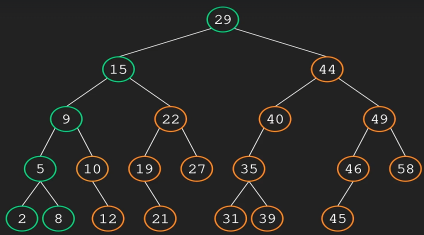

Try not to think in terms of node levels,but rather how they are connected.With the breadth first search.We visited a node (`29`) and then we visited all its direct connections (`15,44`) before moving on to the ones furtheraway (`9,22,40,49..`)

In depth first traversal we start at a vertex and we visit only one of its neighbors. And then from that vertex we just visited, we go to only one of its neighbors and so on. so with each vertex, we're moving away from the vertex we started at. When we reach a dead end, we backtrack one step and try another route. We haven't tried before and the process will continue until we visited all the vertices reachable from the starting vertex. In order for us to achieve this order of traversing, this time, we'll have to use a stack rather than a queue.

The logic is strikingly similar to the one we saw in the previous section (Breadth First Traversal), except we're now using a stack (Pop right) instead of using Queue(Deque) and left popping the node. The underlying logic is the same, but the order in which we visit nodes is managed with a different container

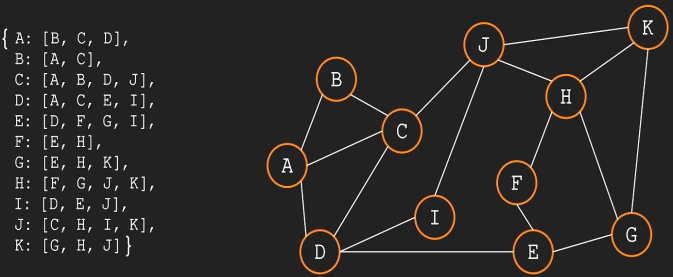

We start with the initial vertex in the stack(`A`) and we mark it as explored.We then pop it(`A`).We visit it and we add all its neighbors(`B,C,D`) to the stack and at the same time mark them as explored.
And then the process will repeat in a loop until there's nothing in the stack.We pop the last element(`D`), we visit it, and then we add all its unexplored neighbors to the stack(`E & I`) to earlier(`B C`)..together as (`B,C,E,I`).
And at the same time, mark them as explored.The logic is strikingly similar to the one we saw in the previous `BFT`, except we're now using a stack,and that's really the only difference.But it's enough to allow us to completely change the order of traversing.

If you remember from the trees chapter, we had a similar situation where the preorder depth first version was identical to the breadth first one, except we used a stack instead of a queue.And it's the same case here.The underlying logic is the same, but the order in which we visit nodes is managed with a different container.

So since the code for DFT method is very similar to BFT we wrote earlier, we can just copy & paste BFT code & modify a few things Highlighted below
- Rename Breadth First Traversal to Depth First Traversal
- Since we are using a regular Python list, we can add the start vertex right when we initialize it `start = [start]` instead of `queue = deque()` &       then `queue.append(start)`
- we need to change `current = queue.popleft()` to `current = stack.pop()`
- replace `queue` instances to `stack` like `while queue:` & `queue.append(adjacent)`

In [ ]:
def depth_first_traversal_iterative(self, start): # You can start with any vertices .e.g E from where the traversal should begin
    ''' Vertex presence check '''
    if start not in self.adjacency_list: # Ensures the graph contains the start vertex.If not found, it raises a clear exception to avoid invalid access.
        raise Exception ("Vertex not in graph")

    ''' Initialize Stack and visited list '''
    stack = [start] # since we are using a regular python list, we can add the start vertex right where we initialise it.  
    visited = [] # keeps track of the order in which nodes are processed.
    ''' Initialize exploration status '''
    explored = {vertex : False for vertex in self.adjacency_list} # each vertices in adjacency_list is marked as false,so when vertice is visited , its
# converted to True for tracking purpose  e.g explored :{ A:False,B:False,C:False,D:False,E:False,F:False,G:False,H:False,I:False,J:False,K:False,}

# explored = {} -this is how regular code looks like,above we have used dictionary comprehension which is a concise & readable way to create dictionaries
# for vertex in self.adjacency_list:
#    explored[vertex] = False '''
    explored[start] = True # E : True
    ''' Main DFT loop '''
    while stack: # Continues until there are no more nodes to explore.
        current = stack.pop() # Removes the recent element (current) from the stack (LIFO behavior) : E is popped
        visited.append(current) # popped node is added to current to pull up its adjacent neighbors,once E is popped, we get D,F & G (left to right)
        ''' Explore adjacent vertices'''       
        for adjacent in self.adjacency_list[current]: # when while loop restarts G is popped(From right) & we get H,K, 
            if not explored[adjacent]: # becoz of stack we get to pop the recently explored vertex 
# if we had choosen list instead of dictionary to search for vertices & marking them as explored,the complexity would have been O(n).With dictionary 
# we have instant access to all keys, making this if clause O(1) operation & thats why dictionary was choosen '''
                stack.append(adjacent)#if choosen node is False,we append it to stack,if True we skip next code,go back to For loop & check next neighbor
                explored[adjacent] = True # and mark it as true, so we dont double count it or duplicate in stack
    return visited

1. We have the `explored` dictionary which is pre marked as `False` so that at later time while traversing thru the graph if we come across new vertices we can mark them as True. This flag will help us add unique neighbors to stack , to be popped later
2. We have `visited` list to capture all unique vertices, whenever they are popped from stack
3. Current is used as a placeholder to
    - Store the popped vertex
    - Add it to the visited list as final output
    - Use it in for loop to explore neighbors of the `current` vertex
4. The moment a new vertex is found (which is not flagged as False in explored Dictionary), it is added to the stack (for pop) and flagged as True to avoid any repetition or duplicate discovery

In [125]:
# Lets put it all together end to end and execute DFT Iterative 
''' Initialization '''
class Graph:
    def __init__(self): 
        self.adjacency_list = {} # Instance
# Creating an empty dictionary (instead of list) to hold graph's vertices as keys, and their neighbors (adjacent vertices) as values.
    ''' Adding a Vertex '''
    def add_vertex(self, vertex): # methods
        if vertex in self.adjacency_list: # checking if that person (vertex) is already in your address book (dictionary).
            raise Exception ("Vertex already in graph") 
        self.adjacency_list[vertex] = [] # If they’re not, you add them and associate an empty list, which will later be filled with their connections.
        return self
# e.g self.adjacency_list["Alice"] = [] means Alice is now part of the graph, but has no connections yet.
# {} holds pairs → vertex: [list of neighbors] & [] is the list of neighbors for each vertex
# Think of it like this: you're building a phonebook where each person (vertex) has a list of contacts (adjacent vertices). 
# The phonebook itself is a dictionary, but each person’s contact list is a list.
    ''' Adding an Edge '''    
    def add_edge(self, vertex1, vertex2): # since its undirected graph, we are looking for handshake from both parties
        if vertex1 not in self.adjacency_list or vertex2 not in self.adjacency_list:
            raise Exception ("Invalid vertices") # First, you're verifying that both people already exist in the graph.
        self.adjacency_list[vertex1].append(vertex2) # Second you're updating each person’s list of friends to include the other.
        self.adjacency_list[vertex2].append(vertex1)
        return self


    def depth_first_traversal_iterative(self, start): # You can start with any vertices .e.g E from where the traversal should begin
        ''' Vertex presence check '''
        if start not in self.adjacency_list: # Ensures the graph contains the start vertex.If not found, it raises a clear exception to avoid invalid access.
            raise Exception ("Vertex not in graph")
    
        ''' Initialize Stack and visited list '''
        stack = [start] # since we are using a regular python list, we can add the start vertex right where we initialise it.  
        visited = [] # keeps track of the order in which nodes are processed.
        ''' Initialize exploration status '''
        explored = {vertex : False for vertex in self.adjacency_list} # each vertices in adjacency_list is marked as false,so when vertice is visited , its
    # converted to True for tracking purpose  e.g explored :{ A:False,B:False,C:False,D:False,E:False,F:False,G:False,H:False,I:False,J:False,K:False,}
    
    # explored = {} -this is how regular code looks like,above we have used dictionary comprehension which is a concise & readable way to create dictionaries
    # for vertex in self.adjacency_list:
    #    explored[vertex] = False '''
        explored[start] = True # E : True
        ''' Main DFT loop '''
        while stack: # Continues until there are no more nodes to explore.
            current = stack.pop() # Removes the recent element (current) from the stack (LIFO behavior) : E is popped
            visited.append(current) # popped node is added to current to pull up its adjacent neighbors,once E is popped, we get D,F & G (left to right)
            ''' Explore adjacent vertices'''       
            for adjacent in self.adjacency_list[current]: # when while loop restarts G is popped(From right) & we get H,K, 
                if not explored[adjacent]: # becoz of stack we get to pop the recently explored vertex 
    # if we had choosen list instead of dictionary to search for vertices & marking them as explored,the complexity would have been O(n).With dictionary 
    # we have instant access to all keys, making this if clause O(1) operation & thats why dictionary was choosen '''
                    stack.append(adjacent)#if choosen node is False,we append it to stack,if True we skip next code,go back to For loop & check next neighbor
                    explored[adjacent] = True # and mark it as true, so we dont double count it or duplicate in stack
        return visited
   

In [127]:
graph=Graph()

In [129]:
graph.add_vertex("A").add_vertex("B").add_vertex("C").add_vertex("D").add_vertex("E").add_vertex("F").add_vertex("G").add_vertex("H").add_vertex("I").add_vertex("J").add_vertex("K")

In [139]:
graph.adjacency_list

{'A': [],
 'B': [],
 'C': [],
 'D': [],
 'E': [],
 'F': [],
 'G': [],
 'H': [],
 'I': [],
 'J': [],
 'K': []}

In [137]:
print(graph.adjacency_list)

{'A': [], 'B': [], 'C': [], 'D': [], 'E': [], 'F': [], 'G': [], 'H': [], 'I': [], 'J': [], 'K': []}


In [141]:
graph.add_edge("A","B").add_edge("A","D").add_edge("A","C").add_edge("B","C").add_edge("C","D").add_edge("C","J").add_edge("J","I").add_edge("K","J").add_edge("I","D").add_edge("H","F").add_edge("H","G").add_edge("F","E").add_edge("E","G").add_edge("D","E").add_edge("G","K").add_edge("H","K").add_edge("H","J")


In [160]:
print(graph.adjacency_list)

{'A': ['B', 'D', 'C'], 'B': ['A', 'C'], 'C': ['A', 'B', 'D', 'J'], 'D': ['A', 'C', 'I', 'E'], 'E': ['F', 'G', 'D'], 'F': ['H', 'E'], 'G': ['H', 'E', 'K'], 'H': ['F', 'G', 'K', 'J'], 'I': ['J', 'D'], 'J': ['C', 'I', 'K', 'H'], 'K': ['J', 'G', 'H']}


In [149]:
for vertices, edges in graph.adjacency_list.items():
    print( vertices, ":", edges)

A : ['B', 'D', 'C']
B : ['A', 'C']
C : ['A', 'B', 'D', 'J']
D : ['A', 'C', 'I', 'E']
E : ['F', 'G', 'D']
F : ['H', 'E']
G : ['H', 'E', 'K']
H : ['F', 'G', 'K', 'J']
I : ['J', 'D']
J : ['C', 'I', 'K', 'H']
K : ['J', 'G', 'H']


In [151]:
graph.depth_first_traversal_iterative("E")

['E', 'D', 'I', 'J', 'H', 'K', 'C', 'B', 'A', 'G', 'F']

In [162]:
graph.adjacency_list

{'A': ['B', 'D', 'C'],
 'B': ['A', 'C'],
 'C': ['A', 'B', 'D', 'J'],
 'D': ['A', 'C', 'I', 'E'],
 'E': ['F', 'G', 'D'],
 'F': ['H', 'E'],
 'G': ['H', 'E', 'K'],
 'H': ['F', 'G', 'K', 'J'],
 'I': ['J', 'D'],
 'J': ['C', 'I', 'K', 'H'],
 'K': ['J', 'G', 'H']}

**What if we want to change the order of adjacency_list in ascending ?**

Right now sorted() just gives you a sorted view of the keys, but it doesn’t actually change the dictionary itself. Python dictionaries preserve insertion order, not sort order. If you want your graph.adjacency_list itself to be sorted, you need to rebuild it in sorted order.


In [169]:
graph.adjacency_list = {
    vertex: sorted(neighbors)
    for vertex, neighbors in sorted(graph.adjacency_list.items())
}
print(graph.adjacency_list)

{'A': ['B', 'C', 'D'], 'B': ['A', 'C'], 'C': ['A', 'B', 'D', 'J'], 'D': ['A', 'C', 'E', 'I'], 'E': ['D', 'F', 'G'], 'F': ['E', 'H'], 'G': ['E', 'H', 'K'], 'H': ['F', 'G', 'J', 'K'], 'I': ['D', 'J'], 'J': ['C', 'H', 'I', 'K'], 'K': ['G', 'H', 'J']}


In [171]:
graph.adjacency_list

{'A': ['B', 'C', 'D'],
 'B': ['A', 'C'],
 'C': ['A', 'B', 'D', 'J'],
 'D': ['A', 'C', 'E', 'I'],
 'E': ['D', 'F', 'G'],
 'F': ['E', 'H'],
 'G': ['E', 'H', 'K'],
 'H': ['F', 'G', 'J', 'K'],
 'I': ['D', 'J'],
 'J': ['C', 'H', 'I', 'K'],
 'K': ['G', 'H', 'J']}

#### Time And Space Complexity
When it comes to the complexities they are the same as the breadth first, since they both perform the same operations, we just changed the queue to a stack, but that doesn't affect the performance. We still have a time complexity of O(V+E) and a memory usage of O(V)

##### Time :  *O* (V + E)
##### Space : *O* (V)

### Depth First Traversal Recursive

The same depth first algorithm could also be written with recursion without changing its core logic. We might visit vertices in a slightly different order, just like the preorder traversal for trees, where the iterative version traversed the right side of the tree, and the recursive one the left side, but the underlying logic stays the same with each iteration or with each function call. In the case of recursion, we try to go away from the vertices we visited so far

Notice how, with the recursive version, we try to visit the first unexplored neighbor we find in each adjacency list, as opposed to the iterative version where we first marked all of them as explored, and we visited the last one. This doesn't change the fact that we're still doing depth first traversing, but the order in which we visit vertices is different. Previously we went from `E` to `G` to `K` to `J`. Notice how we traverse to the last neighbor of each vertex(highlighted below)..thats because we pop the last vertex(`LIFO`), hence the last neighbor is first to be popped and added to visited list

 'E': ['D', 'F', `'G'`]
 
 'G': ['E', 'H', `'K'`]

 'K': ['G', 'H', `'J'`]

And with the recursive version, as you can see below, we went in the other direction from E to D to A, traversing using first neighbor(`FIFO`)

'E': [`'D'`, 'F', 'G']

'D': [`'A'`, 'C', 'E', 'I']

'A': [`'B'`, 'C', 'D']


In [1]:
def dft_recursive(self, start):
    if start not in self.adjacency_list:
        raise Exception("Vertex not in graph")
    visited = [] # We need the visited and the explored containers, but we don't want to immediately mark the start as explored.
    explored = {vertex:False for vertex in self.adjacency_list}
    # We don't need a separate stack, since recursion will mimic it by using the runtime stack.

    def _traverse(current):
        visited.append(current)
        explored[current] = True
        for adjacent in self.adjacency_list[current]:
            if not explorer[adjacent]:
                _traverse(adjacent)
        return

    _traverse(start) # placing this at the bottom simply initiates the recursion. Without that nothing would happen,you’d just return an empty visited
# When all recursive calls finish, the very first call above(_traverse(start)) also finishes.-At that point, execution continues with the next line 
# in dft_recursive, which is return visited(below)
    return visited

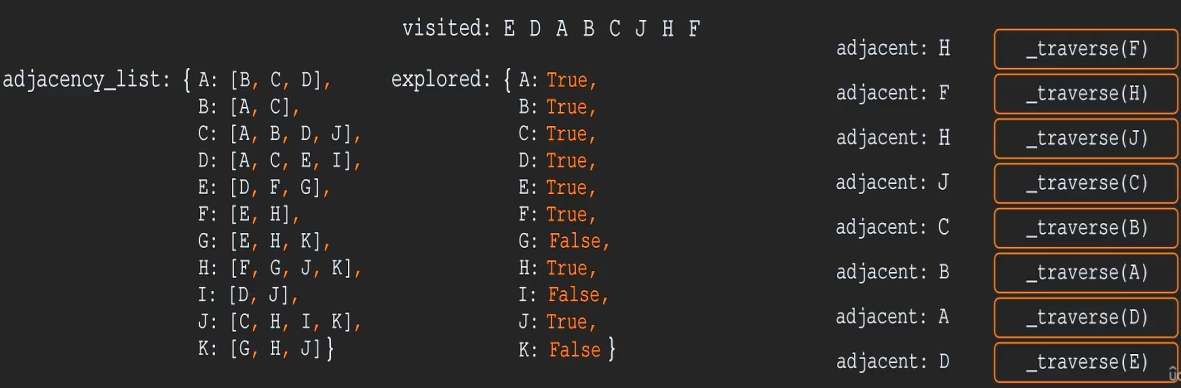

In [18]:
# Now lets execute the algorithm end to end
''' Initialization '''
class Graph:
    def __init__(self): 
        self.adjacency_list = {} # Instance
# Creating an empty dictionary (instead of list) to hold graph's vertices as keys, and their neighbors (adjacent vertices) as values.
    ''' Adding a Vertex '''
    def add_vertex(self, vertex): # methods
        if vertex in self.adjacency_list: # checking if that person (vertex) is already in your address book (dictionary).
            raise Exception ("Vertex already in graph") 
        self.adjacency_list[vertex] = [] # If they’re not, you add them and associate an empty list, which will later be filled with their connections.
        return self
# e.g self.adjacency_list["Alice"] = [] means Alice is now part of the graph, but has no connections yet.
# {} holds pairs → vertex: [list of neighbors] & [] is the list of neighbors for each vertex
# Think of it like this: you're building a phonebook where each person (vertex) has a list of contacts (adjacent vertices). 
# The phonebook itself is a dictionary, but each person’s contact list is a list.
    ''' Adding an Edge '''    
    def add_edge(self, vertex1, vertex2): # since its undirected graph, we are looking for handshake from both parties
        if vertex1 not in self.adjacency_list or vertex2 not in self.adjacency_list:
            raise Exception ("Invalid vertices") # First, you're verifying that both people already exist in the graph.
        self.adjacency_list[vertex1].append(vertex2) # Second you're updating each person’s list of friends to include the other.
        self.adjacency_list[vertex2].append(vertex1)
        return self

    ''' For Printing output in horizontal fashion'''
    def print_graph(self):
        for vertices,edges in self.adjacency_list.items():
            print(f"{vertices}:{edges}")


    def dft_recursive(self, start):
        if start not in self.adjacency_list:
            raise Exception("Vertex not in graph")
        visited = [] # We need the visited and the explored containers, but we don't want to immediately mark the start as explored.
        explored = {vertex:False for vertex in self.adjacency_list}
        # We don't need a separate stack, since recursion will mimic it by using the runtime stack.

        def _traverse(current):
            visited.append(current)
            explored[current] = True
            for adjacent in self.adjacency_list[current]:
                if not explored[adjacent]:
                    _traverse(adjacent)
            return
    
        _traverse(start)
        return visited

In [20]:
graph=Graph()

In [22]:
graph.add_vertex("A").add_vertex("B").add_vertex("C").add_vertex("D").add_vertex("E").add_vertex("F").add_vertex("G").add_vertex("H").add_vertex("I").add_vertex("J").add_vertex("K")

In [24]:
graph.add_edge("A","B").add_edge("A","D").add_edge("A","C").add_edge("B","C").add_edge("C","D").add_edge("C","J").add_edge("J","I").add_edge("K","J").add_edge("I","D").add_edge("H","F").add_edge("H","G").add_edge("F","E").add_edge("E","G").add_edge("D","E").add_edge("G","K").add_edge("H","K").add_edge("H","J")
print(graph.adjacency_list)

{'A': ['B', 'D', 'C'], 'B': ['A', 'C'], 'C': ['A', 'B', 'D', 'J'], 'D': ['A', 'C', 'I', 'E'], 'E': ['F', 'G', 'D'], 'F': ['H', 'E'], 'G': ['H', 'E', 'K'], 'H': ['F', 'G', 'K', 'J'], 'I': ['J', 'D'], 'J': ['C', 'I', 'K', 'H'], 'K': ['J', 'G', 'H']}


In [26]:
for vertices, edges in graph.adjacency_list.items():
    print( vertices,":",edges)

A : ['B', 'D', 'C']
B : ['A', 'C']
C : ['A', 'B', 'D', 'J']
D : ['A', 'C', 'I', 'E']
E : ['F', 'G', 'D']
F : ['H', 'E']
G : ['H', 'E', 'K']
H : ['F', 'G', 'K', 'J']
I : ['J', 'D']
J : ['C', 'I', 'K', 'H']
K : ['J', 'G', 'H']


In [30]:
graph.dft_recursive("E")
# If you notice, for every vertex, their first neighbor becomes their neighbor in the visited list

['E', 'F', 'H', 'G', 'K', 'J', 'C', 'A', 'B', 'D', 'I']

#### Time And Space Complexity

The first two things we do in the inner function is we visit(`visited.append(current)`) and we mark the current vertex as explored(`explored[current]`).And at if condition(`if not explored[adjacent]`) the condition to invoke traverse is for the vertex we're currently at in the loop to not be explored.This means that traverse will be called only once for each vertex, which in the big O notation would be O(V) times.

At for loop(`for adjacent in self.adjacency_list[current]`)we iterate over the edges of the current vertex, and as we already mentioned, we call traverse for every vertex only once.This means that at `for loop` we have an O(E) complexity.

So in total we iterate over all the edges and the vertices in the graph.This will therefore be O(V+E), just like the iterative version.The memory utilization is also the same as the other solutions.We need extra space for the explored dictionary, but this time we don't use a stack that we defined,but rather the built in call stack.All the recursive calls use extra memory, and as you just saw, we can have a lot of them at the sametime on the stack.In extreme cases, we would have the number of calls to traverse, but never more than that.The final space complexity is therefore O(V)

##### Time :  *O* (V + E)
##### Space : *O* (V)

### Graph Traversal Use Cases

#### 1. Breadth-First Traversal (BFT)
- **Shortest Path in Unweighted Graphs**  
  Finds the minimum number of edges between two nodes.
- **Level Order Exploration**  
  Useful for exploring nodes layer by layer (e.g., social networks).
- **Connectivity Check**  
  Determines if all nodes are reachable from a given source.
- **Finding Bipartite Graphs**  
  Helps in checking whether a graph can be divided into two sets.

---

#### 2. Depth-First Traversal (DFT) - Recursive
- **Path Finding**  
  Explores possible paths deeply before backtracking.
- **Cycle Detection**  
  Identifies cycles in directed or undirected graphs.
- **Topological Sorting**  
  Used in scheduling tasks with dependencies.
- **Connected Components**  
  Finds distinct subgraphs in disconnected graphs.

---

#### 3. Depth-First Traversal (DFT) - Iterative
- **Memory-Efficient Exploration**  
  Avoids recursion stack overflow in large graphs.
- **Maze/Path Simulation**  
  Useful in iterative simulations of paths or puzzles.
- **Graph Traversal in Limited Environments**  
  Preferred in systems where recursion is restricted.
- **Order of Node Processing Control**  
  Stack-based approach allows explicit control of traversal order.

---

#### 4. Breadth-First vs Depth-First (Comparative Use)
- **BFT for Shortest Path**  
  Best when minimal steps are required.
- **DFT for Exhaustive Search**  
  Useful when exploring all possible paths.
- **BFT for Layered Problems**  
  Ideal for problems involving levels or distances.
- **DFT for Backtracking Problems**  
  Effective in puzzles, constraint satisfaction, and exhaustive search.